# Semiconductor Manufacturing Fault Detection using the SECOM Dataset

This notebook builds a classical machine learning workflow for predicting SECOM pass/fail outcomes from high-dimensional manufacturing process parameters.


![Electronics manufacturing line](../reports/figures/electronics_manufacturing.png)

*Illustrative view of electronic devices being assembled in a clean manufacturing environment.*


## Contents

1. [Introduction](#1-introduction)
2. [Vocabulary](#2-vocabulary)
3. [Problem Formulation](#3-problem-formulation)
4. [Dataset Description](#4-dataset-description)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Missing Values and Data Quality](#6-missing-values-and-data-quality)
7. [Preprocessing Strategy](#7-preprocessing-strategy)
8. [Baseline Models](#8-baseline-models)
9. [Handling Class Imbalance](#9-handling-class-imbalance)
10. [Model Evaluation](#10-model-evaluation)
11. [Additional Classical Models](#11-additional-classical-models)
12. [PCA / Dimensionality Reduction](#12-pca--dimensionality-reduction)
13. [Discussion and Limitations](#13-discussion-and-limitations)
14. [Conclusion](#14-conclusion)

## 1. Introduction

Semiconductor manufacturing produces many numerical measurements during each process run. In this notebook, one **process run** means one row / manufacturing observation in the SECOM dataset.

The project goal is to predict whether a process run passes or fails quality control while handling missing values, noisy process parameters, and strong class imbalance. The workflow uses classical machine learning models and keeps preprocessing leakage-safe.


## 2. Vocabulary

Before working with the dataset, it is useful to clarify the main terms used in this notebook.

- **Process run**: one row in the SECOM dataset. It represents one manufacturing observation collected during production.
- **Process parameter**: one numerical measurement from the manufacturing process. For example, in a factory producing electronic devices, temperature, pressure, alignment, machine speed, or an electrical test reading could all be process parameters.
- **Target label**: the value the model tries to predict. In this project, it indicates whether the process run passed or failed quality control.
- **SECOM label convention**: `1` means fail/faulty and `-1` means pass/normal.
- **Pass sample**: a process run labeled as normal.
- **Fail sample**: a process run labeled as faulty.
- **Class imbalance**: a situation where one class is much more common than the other. In this dataset, pass samples are much more common than fail samples.


## 3. Problem Formulation

This is a binary classification task. For each process run, the model receives a vector of process parameter measurements and predicts whether the run passes or fails quality control.

Mathematically, let $x_i \in \mathbb{R}^p$ be the process parameter vector for process run $i$, where $p$ is the number of measured parameters. Let $y_i \in \{-1, 1\}$ be the quality label, where `1` means Fail / faulty and `-1` means Pass / normal.

The goal is to learn a function $f(x_i)$ that generalizes to unseen process runs, with special attention to detecting the rare Fail class.


## 4. Dataset Description

The SECOM dataset contains anonymized numerical measurements from semiconductor manufacturing. Each row is a process run, each feature column is a process parameter, and the target label indicates the quality outcome.

The original label convention is important: `1` means Fail / faulty and `-1` means Pass / normal. Because the features are anonymized, the analysis focuses on missingness, variance, target imbalance, and predictive performance rather than physical interpretation of individual parameters.


## 5. Exploratory Data Analysis

This section loads the SECOM data, combines the feature matrix with the target labels, and inspects the dataset before modeling. The main EDA goals are to understand class imbalance, missing values, constant parameters, and other data quality issues that affect preprocessing.

The findings from this section guide the preprocessing strategy used later in the modeling pipeline.


In [1]:
# Imports
from pathlib import Path
import sys

# Make the project src/ folder importable from the notebook.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Basic tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn modules
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold

# Imbalanced learning tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)

# Project utilities
from src.evaluation import (
    evaluate_model_cv,
    get_fail_probabilities,
    get_oof_fail_probabilities,
    summarize_model,
)

In [2]:
# Define paths to the data files
DATA_DIR = Path("../data/raw")

features_path = DATA_DIR / "secom.data"
labels_path = DATA_DIR / "secom_labels.data"

# Load the data
X_raw = pd.read_csv(features_path, sep=r"\s+", header=None)
y_raw = pd.read_csv(labels_path, sep=r"\s+", header=None)

# Check the shapes of the loaded data
X_raw.shape, y_raw.shape

((1567, 590), (1567, 2))

In [3]:
# Display the first few rows of the features
X_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [4]:
# Display the first few rows of the labels
y_raw.head()

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [5]:
# Let's create a clean dataframe by concatenating the features and labels
feature_columns = [f"parameter_{i}" for i in range(X_raw.shape[1])]

X = X_raw.copy()
X.columns = feature_columns

labels = y_raw.copy()
labels.columns = ["target", "timestamp"]

df = X.copy()
df["target"] = labels["target"]
df["timestamp"] = labels["timestamp"]

df.head()

,parameter_0,parameter_1,parameter_2,parameter_3,parameter_4,parameter_5,parameter_6,parameter_7,parameter_8,parameter_9,...,parameter_582,parameter_583,parameter_584,parameter_585,parameter_586,parameter_587,parameter_588,parameter_589,target,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 15:22:00


In [6]:
df.shape

(1567, 592)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, parameter_0 to timestamp
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


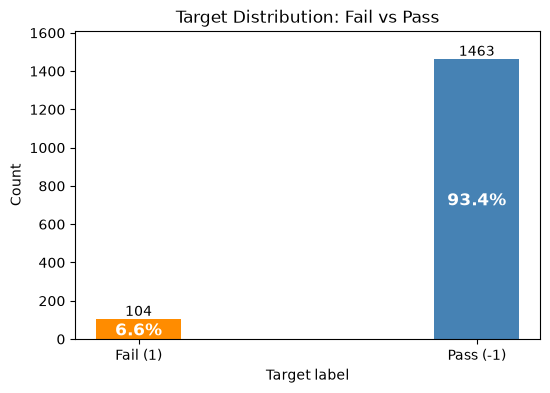

In [8]:
# Let's check for target class distribution
# In SECOM, 1 = Fail and -1 = Pass.
class_order = [1, -1]
class_labels = ["Fail (1)", "Pass (-1)"]

target_counts = df["target"].value_counts().reindex(class_order, fill_value=0)
target_percentages = df["target"].value_counts(normalize=True).reindex(class_order, fill_value=0) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

# Create a bar plot for the target distribution
plt.figure(figsize=(6, 4))

bars = plt.bar(
    class_labels,
    target_summary["count"],
    width=0.25,
    color=["darkorange", "steelblue"]
)

# Add value labels on top of the bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = target_summary.iloc[i]["percentage"]

    # Add the count label
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

    # Add the percentage label inside the bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # center of the bar on X
        (height / 2) - 10,                   # center of the bar on Y with a small offset
        f"{percentage:.1f}%",                # only the percentage
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

# Set the title and labels for the plot
plt.title("Target Distribution: Fail vs Pass")
plt.xlabel("Target label")
plt.ylabel("Count")

plt.ylim(0, target_summary["count"].max() * 1.1)
plt.show()


The target distribution shows strong class imbalance: Pass samples (`-1`) represent `93.4%` of the data, while Fail samples (`1`) represent only `6.6%`.

This means accuracy alone can be misleading. A model that mostly predicts Pass may look accurate while still missing many failed process runs, so later evaluation should focus on Fail-class recall, precision, F1-score, confusion matrix, and PR-AUC.


## 6. Missing Values and Data Quality

SECOM contains missing values across many process parameters, so this section checks missingness from several angles. Feature-level missingness asks which parameters have missing values, row-level missingness asks whether some process runs have unusually many missing parameter values, and target-class missingness compares average missingness between Pass and Fail samples.

This section also checks for constant parameters that add no predictive information. Any preprocessing decisions based on missingness or feature quality should later be fit on the training data only, preferably inside a `scikit-learn` Pipeline.


In [9]:
# Separate process parameter measurements from the target and timestamp columns
feature_cols = [col for col in df.columns if col not in ["target", "timestamp"]]
X_features = df[feature_cols]

print(f"Number of process runs: {X_features.shape[0]}")
print(f"Number of process parameters: {X_features.shape[1]}")


Number of process runs: 1567
Number of process parameters: 590


In [10]:
# Overall missingness across the feature matrix
total_missing = X_features.isna().sum().sum()
total_values = X_features.size
overall_missing_percentage = total_missing / total_values * 100

missing_overview = pd.DataFrame({
    "total_values": [total_values],
    "missing_values": [total_missing],
    "missing_percentage": [overall_missing_percentage]
})

missing_overview


,total_values,missing_values,missing_percentage
0,924530,41951,4.537549


The dataset has missing values, but the global missing percentage only gives a broad overview. A low overall rate can still hide a small group of process parameters with very poor coverage.

The next step is therefore to inspect missingness at the feature level.


In [11]:
# Missing values by feature
missing_summary = pd.DataFrame({
    "missing_count": X_features.isna().sum(),
    "missing_percentage": X_features.isna().mean() * 100
})

missing_summary = missing_summary.sort_values("missing_percentage", ascending=False)

missing_summary.head(20)


,missing_count,missing_percentage
parameter_292,1429,91.193363
parameter_293,1429,91.193363
parameter_158,1429,91.193363
parameter_157,1429,91.193363
parameter_492,1341,85.577537
parameter_85,1341,85.577537
parameter_358,1341,85.577537
parameter_220,1341,85.577537
parameter_244,1018,64.964901
parameter_517,1018,64.964901


In [12]:
# Count how many features exceed useful missingness thresholds
missing_thresholds = [0, 5, 10, 20, 40, 60, 80]

missing_threshold_summary = pd.DataFrame({
    "missing_threshold_percentage": missing_thresholds,
    "number_of_features_above_threshold": [
        (missing_summary["missing_percentage"] > threshold).sum()
        for threshold in missing_thresholds
    ]
})

missing_threshold_summary


,missing_threshold_percentage,number_of_features_above_threshold
0,0,538
1,5,52
2,10,52
3,20,32
4,40,32
5,60,24
6,80,8


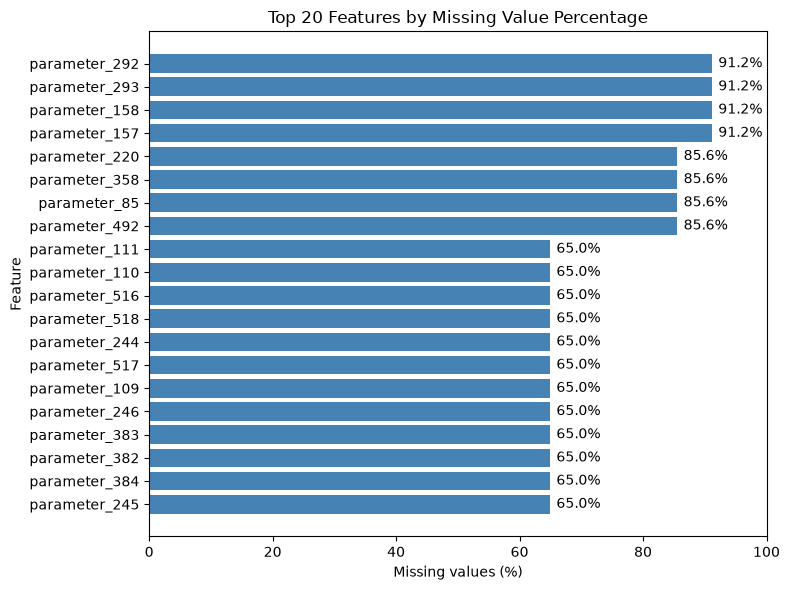

In [13]:
# Visualize the features with the highest missing value percentages
top_missing = missing_summary.head(20).sort_values("missing_percentage")

plt.figure(figsize=(8, 6))
bars = plt.barh(
    top_missing.index,
    top_missing["missing_percentage"],
    color="steelblue"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.title("Top 20 Features by Missing Value Percentage")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


Feature-level missingness is uneven. Many process parameters have at least one missing value, and several parameters are missing for more than `40%` of process runs. A few are missing for more than `80%`, which makes them weak candidates for direct modeling.

A reasonable preprocessing strategy is to remove parameters with extremely high missingness and impute the remaining missing values. These choices should be learned from the training split only.


In [14]:
# Missing values by process run / row
row_missing_summary = pd.DataFrame({
    "missing_count": X_features.isna().sum(axis=1),
    "missing_percentage": X_features.isna().mean(axis=1) * 100,
    "target": df["target"]
})

row_missing_summary[["missing_count", "missing_percentage"]].describe()


,missing_count,missing_percentage
count,1567.000000,1567.000000
mean,26.771538,4.537549
std,13.377518,2.267376
min,4.000000,0.677966
25%,20.000000,3.389831
50%,24.000000,4.067797
75%,32.000000,5.423729
max,152.000000,25.762712


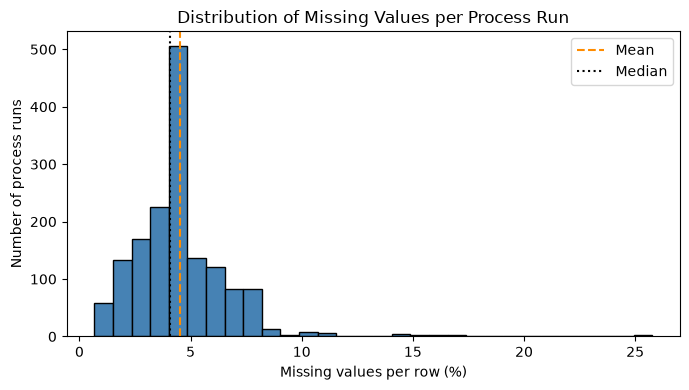

In [15]:
# Distribution of missing values per process run
plt.figure(figsize=(7, 4))

plt.hist(
    row_missing_summary["missing_percentage"],
    bins=30,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    row_missing_summary["missing_percentage"].mean(),
    color="darkorange",
    linestyle="--",
    label="Mean"
)

plt.axvline(
    row_missing_summary["missing_percentage"].median(),
    color="black",
    linestyle=":",
    label="Median"
)

plt.title("Distribution of Missing Values per Process Run")
plt.xlabel("Missing values per row (%)")
plt.ylabel("Number of process runs")
plt.legend()
plt.tight_layout()
plt.show()


The row-level missingness distribution shows that most process runs have a relatively low missing percentage, roughly around `3-6%`. The mean is slightly higher than the median, which suggests a right-skewed distribution caused by a small number of process runs with unusually high missingness.

A few observations have more than `10%` missing values, with extreme cases above `20%`.


In [16]:
# Compare the average percentage of missing parameter values by target class
target_order = [1, -1]
target_labels = ["Fail (1)", "Pass (-1)"]

row_missing_by_target = (
    row_missing_summary
    .groupby("target")[["missing_count", "missing_percentage"]]
    .mean()
    .reindex(target_order)
)

row_missing_by_target.index = target_labels
row_missing_by_target


,missing_count,missing_percentage
Fail (1),25.461538,4.315515
Pass (-1),26.864662,4.553332


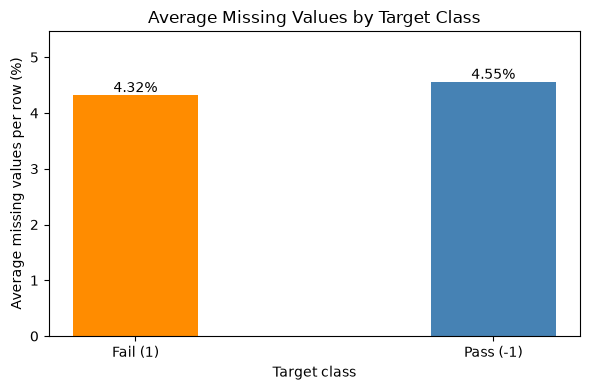

In [17]:
# Plot average missingness by target class
plt.figure(figsize=(6, 4))

bars = plt.bar(
    row_missing_by_target.index,
    row_missing_by_target["missing_percentage"],
    width=0.35,
    color=["darkorange", "steelblue"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Average Missing Values by Target Class")
plt.xlabel("Target class")
plt.ylabel("Average missing values per row (%)")
plt.ylim(0, row_missing_by_target["missing_percentage"].max() * 1.2)
plt.tight_layout()
plt.show()


The row-level view checks whether missing data is concentrated in a small number of process runs. The target-class comparison then checks whether Pass and Fail samples have noticeably different average missingness.

In this dataset, average missingness is similar across target classes, so missingness appears to be a general data quality issue rather than an obvious direct separator between Pass and Fail outcomes.


In [18]:
# Detect constant features, which do not help classification
unique_counts = X_features.nunique(dropna=True)
constant_features = unique_counts[unique_counts <= 1]

print(f"Number of constant features: {len(constant_features)}")

constant_features.head(20)

Number of constant features: 116


parameter_5      1
parameter_13     1
parameter_42     1
parameter_49     1
parameter_52     1
parameter_69     1
parameter_97     1
parameter_141    1
parameter_149    1
parameter_178    1
parameter_179    1
parameter_186    1
parameter_189    1
parameter_190    1
parameter_191    1
parameter_192    1
parameter_193    1
parameter_194    1
parameter_226    1
parameter_229    1
dtype: int64

In [19]:
# Compact data quality summary for preprocessing decisions
data_quality_summary = pd.DataFrame({
    "metric": [
        "features_with_any_missing_values",
        "features_with_more_than_40_percent_missing",
        "features_with_more_than_80_percent_missing",
        "constant_features"
    ],
    "value": [
        (missing_summary["missing_percentage"] > 0).sum(),
        (missing_summary["missing_percentage"] > 40).sum(),
        (missing_summary["missing_percentage"] > 80).sum(),
        len(constant_features)
    ]
})

data_quality_summary


,metric,value
0,features_with_any_missing_values,538
1,features_with_more_than_40_percent_missing,32
2,features_with_more_than_80_percent_missing,8
3,constant_features,116


This data quality check motivates the preprocessing strategy for the next section. The dataset should not be passed directly into a model without handling missing values and uninformative columns.

A realistic first plan is to remove parameters with very high missingness, remove constant features, impute the remaining missing values, and scale features when required by the model. All learned preprocessing steps should be fit on training data only.


## 7. Preprocessing Strategy

Preprocessing is necessary because SECOM has hundreds of anonymized numerical parameters, missing values, constant or near-constant features, and a strongly imbalanced binary target.

The workflow first defines the feature matrix `X` and target vector `y`, then creates a stratified train/test split. Stratification is important because the Fail class is rare, so both splits should preserve the original class ratio as much as possible.

Later model pipelines will handle imputation, feature filtering, scaling, and modeling. The key leakage rule is that learned preprocessing must be fit only on training data or inside cross-validation folds.


The split below creates the objects used by later modeling code. No imputer, scaler, feature filter, PCA step, or model should be fitted before this split.


In [20]:
# Define features and target
X = df[feature_cols]
y = df["target"]

# Create a stratified train/test split before fitting any preprocessing step
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


((1253, 590),
 (314, 590),
 target
 -1    0.933759
  1    0.066241
 Name: proportion, dtype: float64,
 target
 -1    0.933121
  1    0.066879
 Name: proportion, dtype: float64)

## 8. Baseline Models

This section starts with a naive Dummy Classifier and then compares it with the current Logistic Regression baseline. The goal is to separate two questions: what performance can be achieved without learning useful patterns, and how much the first real model improves on that reference point.

Both models are evaluated on the same held-out test set, with `1` treated as the Fail class and `-1` treated as the Pass class.

### 8.1 Dummy Model

The Dummy Classifier is a naive benchmark. With `strategy="prior"`, it learns only the class distribution from the training data and predicts the majority class for every test sample.

This model is not expected to detect failures. Its purpose is to show how misleading accuracy can be when the Pass class dominates the dataset.

In [21]:
# Dummy model: learns only the class distribution
dummy_model = DummyClassifier(strategy="prior", random_state=42)
dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

# In SECOM, 1 = Fail and -1 = Pass.
dummy_fail_class_index = list(dummy_model.classes_).index(1)
dummy_fail_proba = dummy_model.predict_proba(X_test)[:, dummy_fail_class_index]

print(classification_report(
    y_test,
    dummy_pred,
    labels=[1, -1],
    target_names=["Fail (1)", "Pass (-1)"],
    zero_division=0
))

              precision    recall  f1-score   support

    Fail (1)       0.00      0.00      0.00        21
   Pass (-1)       0.93      1.00      0.97       293

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



### 8.2 Logistic Regression Baseline

Logistic Regression is the first real baseline model. It is simple, fast, and a common starting point for binary classification.

The model is wrapped in a `scikit-learn` Pipeline because Logistic Regression cannot handle missing values directly and is sensitive to feature scale. The pipeline applies median imputation, removes constant features, scales the remaining parameters, and fits a class-weighted Logistic Regression model.

In [22]:
# Logistic Regression baseline pipeline
# scikit-learn adjusts class weights inversely proportional to class frequencies.
log_reg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

log_reg_pred = log_reg_pipeline.predict(X_test)

# In SECOM, 1 = Fail and -1 = Pass.
log_reg_fail_class_index = list(log_reg_pipeline.named_steps["classifier"].classes_).index(1)
log_reg_fail_proba = log_reg_pipeline.predict_proba(X_test)[:, log_reg_fail_class_index]

# Keep these aliases for the evaluation cells below.
y_pred = log_reg_pred
y_fail_proba = log_reg_fail_proba

### 8.3 Baseline Evaluation and Comparison

The next cells inspect the Logistic Regression confusion matrix and classification report, then compare the Dummy Classifier and Logistic Regression using the same metrics.

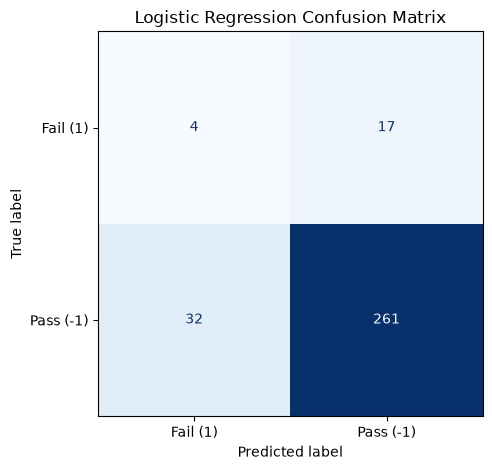

In [23]:
# Confusion matrix for Logistic Regression baseline predictions
# In SECOM, 1 = Fail and -1 = Pass.
cm = confusion_matrix(y_test, log_reg_pred, labels=[1, -1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail (1)", "Pass (-1)"]
)

disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
print(classification_report(
    y_test,
    log_reg_pred,
    labels=[1, -1],
    target_names=["Fail (1)", "Pass (-1)"]
))

              precision    recall  f1-score   support

    Fail (1)       0.11      0.19      0.14        21
   Pass (-1)       0.94      0.89      0.91       293

    accuracy                           0.84       314
   macro avg       0.52      0.54      0.53       314
weighted avg       0.88      0.84      0.86       314



In [25]:
roc_auc = roc_auc_score(y_test == 1, log_reg_fail_proba)
pr_auc = average_precision_score(y_test == 1, log_reg_fail_proba)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.644
PR-AUC: 0.124


In [26]:
baseline_comparison = pd.DataFrame([
    summarize_model("Dummy Classifier", y_test, dummy_pred, dummy_fail_proba),
    summarize_model("Logistic Regression", y_test, log_reg_pred, log_reg_fail_proba),
]).set_index("model")

baseline_comparison.round(3)

,accuracy,balanced_accuracy,fail_precision,fail_recall,fail_f1,roc_auc,pr_auc
model,,,,,,,
Dummy Classifier,0.933,0.500,0.000,0.00,0.00,0.500,0.067
Logistic Regression,0.844,0.541,0.111,0.19,0.14,0.644,0.124


### 8.4 Baseline Evaluation Conclusion

The Dummy Classifier is useful because it shows what happens when the model mostly follows the majority Pass class. It can achieve high accuracy, but it has `0.00` recall for the Fail class because it does not identify failed process runs.

The Logistic Regression baseline improves on the dummy model by detecting some Fail samples. However, Fail-class performance is still weak: precision is `0.11`, recall is `0.19`, F1-score is `0.14`, ROC-AUC is `0.644`, and PR-AUC is `0.124`.

The main lesson is that accuracy is not enough for this dataset. The next section should focus on imbalance-aware strategies that improve Fail-class detection while keeping false alarms manageable.

## 9. Handling Class Imbalance

The baseline comparison shows why imbalance matters: the Dummy Classifier has high accuracy but does not detect failed process runs. This section compares three Logistic Regression variants that address imbalance in different ways.

The original dataset is not changed. Resampling is applied only to the training data inside an `imblearn` Pipeline, so the test set remains untouched.

### 9.1 Imbalance-Aware Strategies

The current Logistic Regression baseline already uses `class_weight="balanced"`, which changes the training loss so mistakes on the rare Fail class receive more weight.

This section adds two resampling approaches:

- **RandomOverSampler** duplicates minority-class training samples.
- **SMOTE** creates synthetic minority-class training samples by interpolating between nearby Fail examples.

Both approaches are used only within the training pipeline to evade Data-leakage.

In [27]:
# Logistic Regression with RandomOverSampler
ros_log_reg_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("sampler", RandomOverSampler(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

ros_log_reg_pipeline.fit(X_train, y_train)

ros_log_reg_pred = ros_log_reg_pipeline.predict(X_test)
ros_fail_class_index = list(ros_log_reg_pipeline.named_steps["classifier"].classes_).index(1)
ros_log_reg_fail_proba = ros_log_reg_pipeline.predict_proba(X_test)[:, ros_fail_class_index]

In [28]:
# Logistic Regression with SMOTE
smote_log_reg_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_log_reg_pipeline.fit(X_train, y_train)

smote_log_reg_pred = smote_log_reg_pipeline.predict(X_test)
smote_fail_class_index = list(smote_log_reg_pipeline.named_steps["classifier"].classes_).index(1)
smote_log_reg_fail_proba = smote_log_reg_pipeline.predict_proba(X_test)[:, smote_fail_class_index]

### 9.2 Imbalance Strategy Comparison

The table below compares the class-weighted Logistic Regression baseline with the two resampling variants. The main focus is the Fail class, especially recall, F1-score, and PR-AUC.

In [29]:
imbalance_comparison = pd.DataFrame([
    summarize_model(
        "LR + class_weight",
        y_test,
        log_reg_pred,
        log_reg_fail_proba
    ),
    summarize_model(
        "LR + RandomOverSampler",
        y_test,
        ros_log_reg_pred,
        ros_log_reg_fail_proba
    ),
    summarize_model(
        "LR + SMOTE",
        y_test,
        smote_log_reg_pred,
        smote_log_reg_fail_proba
    ),
]).set_index("model")

imbalance_comparison.round(3)

,accuracy,balanced_accuracy,fail_precision,fail_recall,fail_f1,roc_auc,pr_auc
model,,,,,,,
LR + class_weight,0.844,0.541,0.111,0.19,0.140,0.644,0.124
LR + RandomOverSampler,0.844,0.541,0.111,0.19,0.140,0.640,0.120
LR + SMOTE,0.847,0.542,0.114,0.19,0.143,0.644,0.122


### 9.3 Imbalance Handling Takeaway

In this initial held-out comparison, resampling does not significantly improve the Logistic Regression baseline. Class weighting and RandomOverSampler produce almost identical results: Fail recall stays at `0.19`, Fail F1-score stays at `0.140`, and PR-AUC remains close to `0.12`.

SMOTE gives a very small improvement in accuracy (`0.847`) and Fail F1-score (`0.143`), but Fail recall remains `0.19`. This means SMOTE does not help the model detect more failed process runs at the default decision threshold.

The main lesson is that imbalance handling alone is not enough here. The next useful step is systematic model evaluation and threshold tuning, because changing the probability threshold may improve the trade-off between catching failures and creating false alarms.

## 10. Model Evaluation

The previous tables used one held-out test split. This section adds a more systematic evaluation step using stratified cross-validation on the training set.

The held-out test set is still kept separate. It is used only after choosing a threshold from training data.

### 10.1 Cross-Validation Setup

Stratified cross-validation keeps the Pass/Fail ratio similar across folds. This is important because the Fail class is rare.

Each model is evaluated as a full Pipeline, so imputation, scaling, feature filtering, and any resampling are fitted only inside the training part of each fold.

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidate_models = {
    "Dummy Classifier": dummy_model,
    "LR + class_weight": log_reg_pipeline,
    "LR + RandomOverSampler": ros_log_reg_pipeline,
    "LR + SMOTE": smote_log_reg_pipeline,
}

The reusable evaluation helpers are imported from `src/evaluation.py`. This keeps the notebook focused on the modeling workflow while keeping repeated metric and cross-validation logic in one place.

In [31]:
cv_results = pd.concat([
    evaluate_model_cv(model_name, model, X_train, y_train, cv)
    for model_name, model in candidate_models.items()
], ignore_index=True)

cv_summary = (
    cv_results
    .drop(columns="fold")
    .groupby("model")
    .agg(["mean", "std"])
)

cv_summary.columns = [f"{metric}_{stat}" for metric, stat in cv_summary.columns]

cv_summary[[
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "fail_recall_mean",
    "fail_recall_std",
    "fail_f1_mean",
    "fail_f1_std",
    "roc_auc_mean",
    "pr_auc_mean",
]].round(3)

,balanced_accuracy_mean,balanced_accuracy_std,fail_recall_mean,fail_recall_std,fail_f1_mean,fail_f1_std,roc_auc_mean,pr_auc_mean
model,,,,,,,,
Dummy Classifier,0.500,0.000,0.000,0.000,0.000,0.000,0.500,0.066
LR + RandomOverSampler,0.560,0.069,0.229,0.139,0.164,0.090,0.599,0.154
LR + SMOTE,0.561,0.070,0.229,0.139,0.166,0.091,0.597,0.157
LR + class_weight,0.558,0.070,0.229,0.139,0.162,0.090,0.601,0.163


### 10.2 Cross-Validation Takeaway

Cross-validation confirms that the Dummy Classifier is not useful for fault detection: its mean Fail recall is `0.000`.

The three Logistic Regression variants perform very similarly. Their mean Fail recall is about `0.229`, while mean Fail F1-score stays around `0.162-0.166`. The standard deviation for Fail recall is high (`0.139`), which suggests that performance is unstable because the Fail class has very few examples.

SMOTE does not clearly outperform the simpler class-weighted Logistic Regression. This supports using the class-weighted model as the main candidate for threshold tuning.

### 10.3 Threshold Tuning

The default classification threshold is `0.50`: predict Fail only when the predicted Fail probability is at least 50%.

For rare failures, this threshold may be too strict. Threshold tuning keeps the trained model the same but changes the probability cutoff used to convert probabilities into class labels.

In [32]:
# Use the simplest imbalance-aware model for threshold tuning.
oof_fail_proba = get_oof_fail_probabilities(log_reg_pipeline, X_train, y_train, cv)

In [33]:
thresholds = np.arange(0.05, 0.96, 0.05)
threshold_rows = []

for threshold in thresholds:
    threshold_pred = np.where(oof_fail_proba >= threshold, 1, -1)
    row = summarize_model(
        f"threshold_{threshold:.2f}",
        y_train,
        threshold_pred,
        oof_fail_proba
    )
    row["threshold"] = threshold
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows)

threshold_results[[
    "threshold",
    "balanced_accuracy",
    "fail_precision",
    "fail_recall",
    "fail_f1",
]].sort_values("fail_f1", ascending=False).head(10).round(3)

,threshold,balanced_accuracy,fail_precision,fail_recall,fail_f1
5,0.30,0.584,0.138,0.301,0.189
3,0.20,0.587,0.132,0.325,0.188
15,0.80,0.569,0.164,0.217,0.187
4,0.25,0.584,0.132,0.313,0.186
17,0.90,0.564,0.176,0.193,0.184
14,0.75,0.567,0.158,0.217,0.183
13,0.70,0.569,0.152,0.229,0.183
6,0.35,0.575,0.134,0.277,0.180
12,0.65,0.567,0.147,0.229,0.179
1,0.10,0.583,0.119,0.349,0.178


In [34]:
best_threshold_row = threshold_results.sort_values(
    ["fail_f1", "fail_recall"],
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["threshold"]

print(f"Best threshold by out-of-fold Fail F1-score: {best_threshold:.2f}")
print(f"Out-of-fold Fail precision: {best_threshold_row['fail_precision']:.3f}")
print(f"Out-of-fold Fail recall: {best_threshold_row['fail_recall']:.3f}")
print(f"Out-of-fold Fail F1-score: {best_threshold_row['fail_f1']:.3f}")

Best threshold by out-of-fold Fail F1-score: 0.30
Out-of-fold Fail precision: 0.138
Out-of-fold Fail recall: 0.301
Out-of-fold Fail F1-score: 0.189


### 10.4 Tuned Threshold Test Evaluation

The threshold was selected using only out-of-fold predictions from the training set. Now it can be applied once to the held-out test set.

This gives a fairer estimate of whether threshold tuning improves the practical Fail-detection trade-off.

In [35]:
threshold_model = clone(log_reg_pipeline)
threshold_model.fit(X_train, y_train)

test_fail_proba = get_fail_probabilities(threshold_model, X_test)
default_threshold_pred = threshold_model.predict(X_test)
tuned_threshold_pred = np.where(test_fail_proba >= best_threshold, 1, -1)

threshold_test_comparison = pd.DataFrame([
    summarize_model(
        "LR threshold 0.50",
        y_test,
        default_threshold_pred,
        test_fail_proba
    ),
    summarize_model(
        f"LR threshold {best_threshold:.2f}",
        y_test,
        tuned_threshold_pred,
        test_fail_proba
    ),
]).set_index("model")

threshold_test_comparison.round(3)

,accuracy,balanced_accuracy,fail_precision,fail_recall,fail_f1,roc_auc,pr_auc
model,,,,,,,
LR threshold 0.50,0.844,0.541,0.111,0.190,0.140,0.644,0.124
LR threshold 0.30,0.815,0.547,0.106,0.238,0.147,0.644,0.124


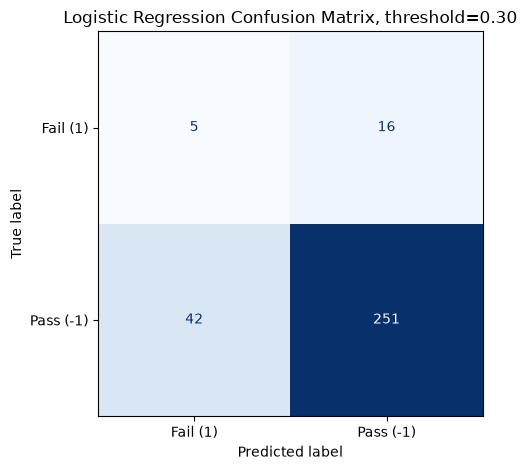

In [36]:
# Confusion matrix after threshold tuning
cm_tuned = confusion_matrix(y_test, tuned_threshold_pred, labels=[1, -1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Fail (1)", "Pass (-1)"]
)

disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Logistic Regression Confusion Matrix, threshold={best_threshold:.2f}")
plt.tight_layout()
plt.show()

### 10.5 Model Evaluation Takeaway

Threshold tuning gives a small improvement in minority-class detection. On the held-out test set, lowering the threshold from `0.50` to `0.30` increases Fail recall from `0.190` to `0.238` and Fail F1-score from `0.140` to `0.147`.

The trade-off is lower overall accuracy: it drops from `0.844` to `0.815`. This is expected because a lower threshold predicts Fail more often, which catches more true failures but also creates more false alarms.

The result is an improvement, but not a dramatic one. The next modeling step should test nonlinear classical models, because Logistic Regression may be too simple for the SECOM feature space.

## 11. Additional Classical Models

Logistic Regression may be too simple for the SECOM feature space because it models a linear decision boundary. This section tests two nonlinear classical models that can capture interactions between process parameters.

The goal is not a large hyperparameter search. The goal is to check whether tree-based classical models provide a stronger minority-class baseline.

### 11.1 Tree-Based Model Candidates

Random Forest and HistGradientBoosting are both classical machine learning models. They do not require feature scaling, but they still need leakage-safe preprocessing for missing values and constant parameters.

Both models use `class_weight="balanced"` so the rare Fail class receives more weight during training.

In [37]:
# Random Forest pipeline
random_forest_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# HistGradientBoosting pipeline
hist_gb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=100,
        class_weight="balanced",
        random_state=42
    ))
])

### 11.2 Cross-Validation Comparison

The models below are evaluated with the same stratified cross-validation setup used earlier. This keeps the comparison consistent and avoids judging models only from a single split.

In [38]:
classical_model_candidates = {
    "LR + class_weight": log_reg_pipeline,
    "Random Forest": random_forest_pipeline,
    "HistGradientBoosting": hist_gb_pipeline,
}

classical_cv_results = pd.concat([
    evaluate_model_cv(model_name, model, X_train, y_train, cv)
    for model_name, model in classical_model_candidates.items()
], ignore_index=True)

classical_cv_summary = (
    classical_cv_results
    .drop(columns="fold")
    .groupby("model")
    .agg(["mean", "std"])
)

classical_cv_summary.columns = [f"{metric}_{stat}" for metric, stat in classical_cv_summary.columns]

classical_cv_summary[[
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "fail_recall_mean",
    "fail_recall_std",
    "fail_f1_mean",
    "fail_f1_std",
    "roc_auc_mean",
    "pr_auc_mean",
]].round(3)

,balanced_accuracy_mean,balanced_accuracy_std,fail_recall_mean,fail_recall_std,fail_f1_mean,fail_f1_std,roc_auc_mean,pr_auc_mean
model,,,,,,,,
HistGradientBoosting,0.510,0.017,0.024,0.032,0.043,0.059,0.697,0.179
LR + class_weight,0.558,0.070,0.229,0.139,0.162,0.090,0.601,0.163
Random Forest,0.500,0.000,0.000,0.000,0.000,0.000,0.674,0.172


### 11.3 Held-Out Test Comparison

After cross-validation, the models are fitted on the full training set and evaluated once on the held-out test set.

The tuned Logistic Regression threshold is included because it was selected using only training-set out-of-fold probabilities.

In [39]:
random_forest_pipeline.fit(X_train, y_train)
hist_gb_pipeline.fit(X_train, y_train)

rf_pred = random_forest_pipeline.predict(X_test)
rf_fail_proba = get_fail_probabilities(random_forest_pipeline, X_test)

hist_gb_pred = hist_gb_pipeline.predict(X_test)
hist_gb_fail_proba = get_fail_probabilities(hist_gb_pipeline, X_test)

classical_test_comparison = pd.DataFrame([
    summarize_model(
        "LR threshold 0.50",
        y_test,
        default_threshold_pred,
        test_fail_proba
    ),
    summarize_model(
        f"LR threshold {best_threshold:.2f}",
        y_test,
        tuned_threshold_pred,
        test_fail_proba
    ),
    summarize_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_fail_proba
    ),
    summarize_model(
        "HistGradientBoosting",
        y_test,
        hist_gb_pred,
        hist_gb_fail_proba
    ),
]).set_index("model")

classical_test_comparison.round(3)

,accuracy,balanced_accuracy,fail_precision,fail_recall,fail_f1,roc_auc,pr_auc
model,,,,,,,
LR threshold 0.50,0.844,0.541,0.111,0.190,0.140,0.644,0.124
LR threshold 0.30,0.815,0.547,0.106,0.238,0.147,0.644,0.124
Random Forest,0.933,0.500,0.000,0.000,0.000,0.761,0.215
HistGradientBoosting,0.930,0.498,0.000,0.000,0.000,0.739,0.184


### 11.4 Classical Model Takeaway

The nonlinear models do not improve Fail-class detection at the default classification threshold. Random Forest predicts no Fail samples in cross-validation, and HistGradientBoosting detects very few Fail samples on average.

However, the probability-ranking metrics tell a more interesting story. On the held-out test set, Random Forest reaches ROC-AUC `0.761` and PR-AUC `0.215`, while HistGradientBoosting reaches ROC-AUC `0.739` and PR-AUC `0.184`. These are higher than Logistic Regression's ROC-AUC `0.644` and PR-AUC `0.124`.

This means the tree-based models may rank failed process runs better, but their default `0.50` decision threshold is too conservative. A sensible next step is threshold tuning for the tree-based model probabilities rather than assuming the default class predictions are final.

## 12. PCA / Dimensionality Reduction

Because SECOM has hundreds of process parameters, PCA may help reduce noise and create lower-dimensional representations for some models.

If PCA is used, it must be placed inside a Pipeline after imputation and scaling, so the transformation is learned only from training data or cross-validation folds.

## 13. Discussion and Limitations

This section will interpret model results and compare the trade-off between detecting failures and avoiding false alarms. It should also explain which metrics are most meaningful for this imbalanced fault detection problem.

Important limitations include anonymized process parameters, a small number of Fail samples, missing values, and limited ability to infer causal process explanations.

## 14. Conclusion

The final conclusion will summarize the best-performing model, the most useful evaluation metrics, the main lessons from the analysis, and recommendations for future work.

The final project should demonstrate a complete, readable, leakage-safe classical ML workflow suitable for course review.